## Stepan-VORONYI-Camp-2026
# Hometask lesson 16: Time Series Forecast
## Import needed libraries

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
file_path = './data/electricity_consumption_and_production.csv'
df = pd.read_csv(file_path)

## Structure of dataset

In [3]:
print(df.head())
print(df.info())

              DateTime  Consumption  Production  Nuclear  Wind  Hydroelectric  \
0  2019-01-01 00:00:00         6352        6527     1395    79           1383   
1  2019-01-01 01:00:00         6116        5701     1393    96           1112   
2  2019-01-01 02:00:00         5873        5676     1393   142           1030   
3  2019-01-01 03:00:00         5682        5603     1397   191            972   
4  2019-01-01 04:00:00         5557        5454     1393   159            960   

   Oil and Gas  Coal  Solar  Biomass  
0         1896  1744      0       30  
1         1429  1641      0       30  
2         1465  1616      0       30  
3         1455  1558      0       30  
4         1454  1458      0       30  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54161 entries, 0 to 54160
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DateTime       54161 non-null  object
 1   Consumption    54161 non-null  int64

## Setting the time index

In [4]:
time_column = 'DateTime'

df[time_column] = pd.to_datetime(df[time_column])
df = df.set_index(time_column).sort_index()

## Selecting the target variable Consumption

In [5]:
target_series = df['Consumption']

print("Our prepaired target series: ")
print(target_series.head())

Our prepaired target series: 
DateTime
2019-01-01 00:00:00    6352
2019-01-01 01:00:00    6116
2019-01-01 02:00:00    5873
2019-01-01 03:00:00    5682
2019-01-01 04:00:00    5557
Name: Consumption, dtype: int64


## Resampling data from hourly to daily

In [6]:
daily_consumption = target_series.resample('D').mean()

print("Data after resampling to daily format:")
print(daily_consumption.head())
print(f"\nTotal number of days in the dataset: {len(daily_consumption)}")

Data after resampling to daily format:
DateTime
2019-01-01    5924.478261
2019-01-02    6322.041667
2019-01-03    7254.083333
2019-01-04    7635.083333
2019-01-05    7423.521739
Freq: D, Name: Consumption, dtype: float64

Total number of days in the dataset: 2270


## Import libraries needed for EDA

In [7]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

## Check Nulls after resampling and fill them with linear interpolation

In [9]:
missing_count = daily_consumption.isna().sum()
print(f"Amount of missing days in the dataset: {missing_count}")

if missing_count > 0:
    print("Missing values detected. Applying linear interpolation...")
    daily_consumption = daily_consumption.interpolate(method='linear')
    print("Missing values successfully filled!")
else:
    print("No missing values detected, data is ready.")

missing_count = daily_consumption.isna().sum()
print(f"Amount of missing days in the dataset after interpolation: {missing_count}")

Amount of missing days in the dataset: 2
Missing values detected. Applying linear interpolation...
Missing values successfully filled!
Amount of missing days in the dataset after interpolation: 0


## Decomposition Visualisation

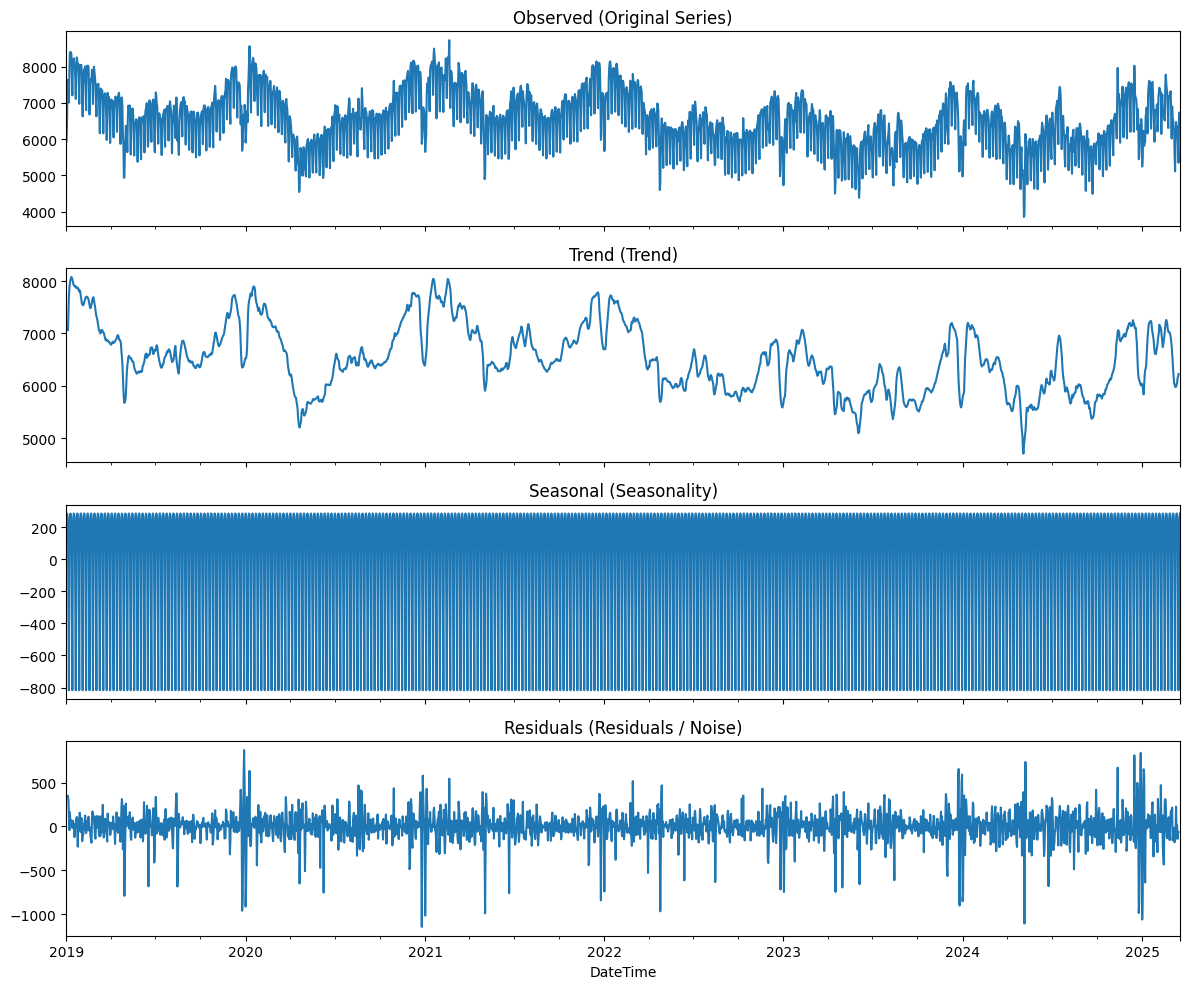

In [10]:
decomposition = seasonal_decompose(daily_consumption, model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=ax1, title='Observed (Original Series)')
decomposition.trend.plot(ax=ax2, title='Trend (Trend)')
decomposition.seasonal.plot(ax=ax3, title='Seasonal (Seasonality)')
decomposition.resid.plot(ax=ax4, title='Residuals (Residuals / Noise)')

plt.tight_layout()
plt.show()

## ACF and PCF Plots

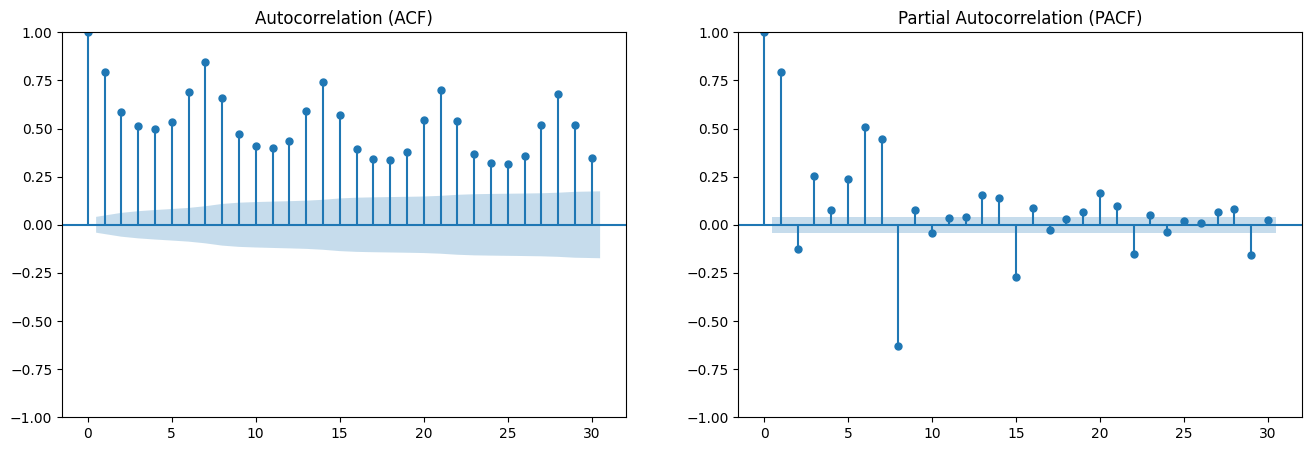

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(daily_consumption.dropna(), lags=30, ax=ax1)
ax1.set_title('Autocorrelation (ACF)')
plot_pacf(daily_consumption.dropna(), lags=30, ax=ax2)
ax2.set_title('Partial Autocorrelation (PACF)')

plt.show()

## ADF test for stationarity

In [12]:
print(" Results of the ADF Test ")
result = adfuller(daily_consumption.dropna())

print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:')

for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

if result[1] <= 0.05:
    print("\nConclusion: p-value <= 0.05. Null hypothesis rejected. The series is STATIONARY.")
else:
    print("\nConclusion: p-value > 0.05. Null hypothesis NOT rejected. The series is NON-STATIONARY (has trend or seasonality).")

 Results of the ADF Test 
ADF Statistic: -3.3884
p-value: 0.0114
Critical Values:
   1%: -3.4333
   5%: -2.8628
   10%: -2.5675

Conclusion: p-value <= 0.05. Null hypothesis rejected. The series is STATIONARY.


## Split Dataset on Train Test

In [13]:
horizons = [15, 30, 45]
max_horizon = max(horizons)
train_data = daily_consumption.iloc[:-max_horizon]
test_data = daily_consumption.iloc[-max_horizon:]

print(f"Training set size: {len(train_data)} days")
print(f"Test set size (validation): {len(test_data)} days")

Training set size: 2225 days
Test set size (validation): 45 days


## Building a Smart Baseline model

In [14]:
smart_baseline_forecast = train_data.iloc[-max_horizon:].values
smart_baseline_series = pd.Series(smart_baseline_forecast, index=test_data.index)

## Train Sarimax Model

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

model_sarima = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fitted = model_sarima.fit(disp=False)
sarima_forecast_series = pd.Series(sarima_fitted.forecast(steps=max_horizon), index=test_data.index)

## Prepare specific format for Prophet model

In [17]:
%pip install prophet
from prophet import Prophet
import xgboost as xgb


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Importing plotly failed. Interactive plots will not work.


Note: you may need to restart the kernel to use updated packages.


In [18]:
horizons = [15, 30, 45]
max_horizon = max(horizons)

train_data = daily_consumption.iloc[:-max_horizon]
test_data = daily_consumption.iloc[-max_horizon:]

In [19]:
def evaluate_forecast(true_values, forecast_values, horizons=[15, 30, 45]):
    results = {}
    for h in horizons:
        y_true = true_values.iloc[:h]
        y_pred = forecast_values.iloc[:h]
        
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        results[f'{h} days'] = {
            'MAPE (%)': round(mape, 2),
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2)
        }
    return pd.DataFrame(results)

## Train Prophet model

In [20]:
prophet_train = train_data.reset_index().rename(columns={train_data.index.name: 'ds', 'Consumption': 'y'})
model_prophet = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)
model_prophet.fit(prophet_train)
future = model_prophet.make_future_dataframe(periods=max_horizon, freq='D')
forecast_prophet = model_prophet.predict(future)
prophet_forecast_series = pd.Series(forecast_prophet['yhat'].iloc[-max_horizon:].values, index=test_data.index)

16:02:50 - cmdstanpy - INFO - Chain [1] start processing
16:02:51 - cmdstanpy - INFO - Chain [1] done processing


## XGBoost

In [21]:
def create_features(series):
    df_features = pd.DataFrame(index=series.index)
    df_features['dayofweek'] = series.index.dayofweek
    df_features['dayofmonth'] = series.index.day
    df_features['lag_7'] = series.shift(7)
    df_features['lag_14'] = series.shift(14)
    df_features['target'] = series.values
    return df_features.dropna()

features_df = create_features(daily_consumption)
X_train = features_df.iloc[:-max_horizon].drop(columns=['target'])
y_train = features_df.iloc[:-max_horizon]['target']
X_test = features_df.iloc[-max_horizon:].drop(columns=['target'])

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb.fit(X_train, y_train)
xgb_forecast_series = pd.Series(model_xgb.predict(X_test), index=test_data.index)

## Calculation of metrics

In [22]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

naive_results = evaluate_forecast(test_data, smart_baseline_series)
sarima_results = evaluate_forecast(test_data, sarima_forecast_series)
prophet_results = evaluate_forecast(test_data, prophet_forecast_series)
xgb_results = evaluate_forecast(test_data, xgb_forecast_series)

## Review the results

In [25]:
print("\n[1] Smart Naive Model:")
print(naive_results)

print("\n[2] SARIMA Model:")
print(sarima_results)

print("\n[3] Prophet Model:")
print(prophet_results)

print("\n[4] XGBoost Model:")
print(xgb_results)


[1] Smart Naive Model:
          15 days  30 days  45 days
MAPE (%)    11.58    11.54    12.37
MAE        813.63   812.58   812.28
RMSE       934.43   967.40   988.20

[2] SARIMA Model:
          15 days  30 days  45 days
MAPE (%)     3.40     3.20     6.31
MAE        236.90   225.28   401.83
RMSE       328.73   303.57   514.19

[3] Prophet Model:
          15 days  30 days  45 days
MAPE (%)     8.96     9.04     7.71
MAE        633.64   640.24   527.19
RMSE       712.24   700.24   602.80

[4] XGBoost Model:
          15 days  30 days  45 days
MAPE (%)     6.68     5.71     6.83
MAE        463.95   401.74   448.46
RMSE       542.17   490.91   552.69


## MAPE

In [28]:
n_mape = naive_results.T.iloc[:, 0].rename('Naive (Smart)')
s_mape = sarima_results.T.iloc[:, 0].rename('SARIMA')
p_mape = prophet_results.T.iloc[:, 0].rename('Prophet (Meta)')
x_mape = xgb_results.T.iloc[:, 0].rename('XGBoost')

## Visualisation

In [29]:
mape_comparison = pd.concat([n_mape, s_mape, p_mape, x_mape], axis=1)
mape_comparison.index = ['15 days horizon', '30 days horizon', '45 days horizon']

styled_table = mape_comparison.style.background_gradient(cmap="RdYlGn_r", axis=None)\
    .format("{:.2f}%")\
    .set_caption("Comparison of MAPE (%) — Lower is better (Green)")

styled_table

,Naive (Smart),SARIMA,Prophet (Meta),XGBoost
15 days horizon,11.58%,3.40%,8.96%,6.68%
30 days horizon,11.54%,3.20%,9.04%,5.71%
45 days horizon,12.37%,6.31%,7.71%,6.83%


## Final Visualistion of Forecasts

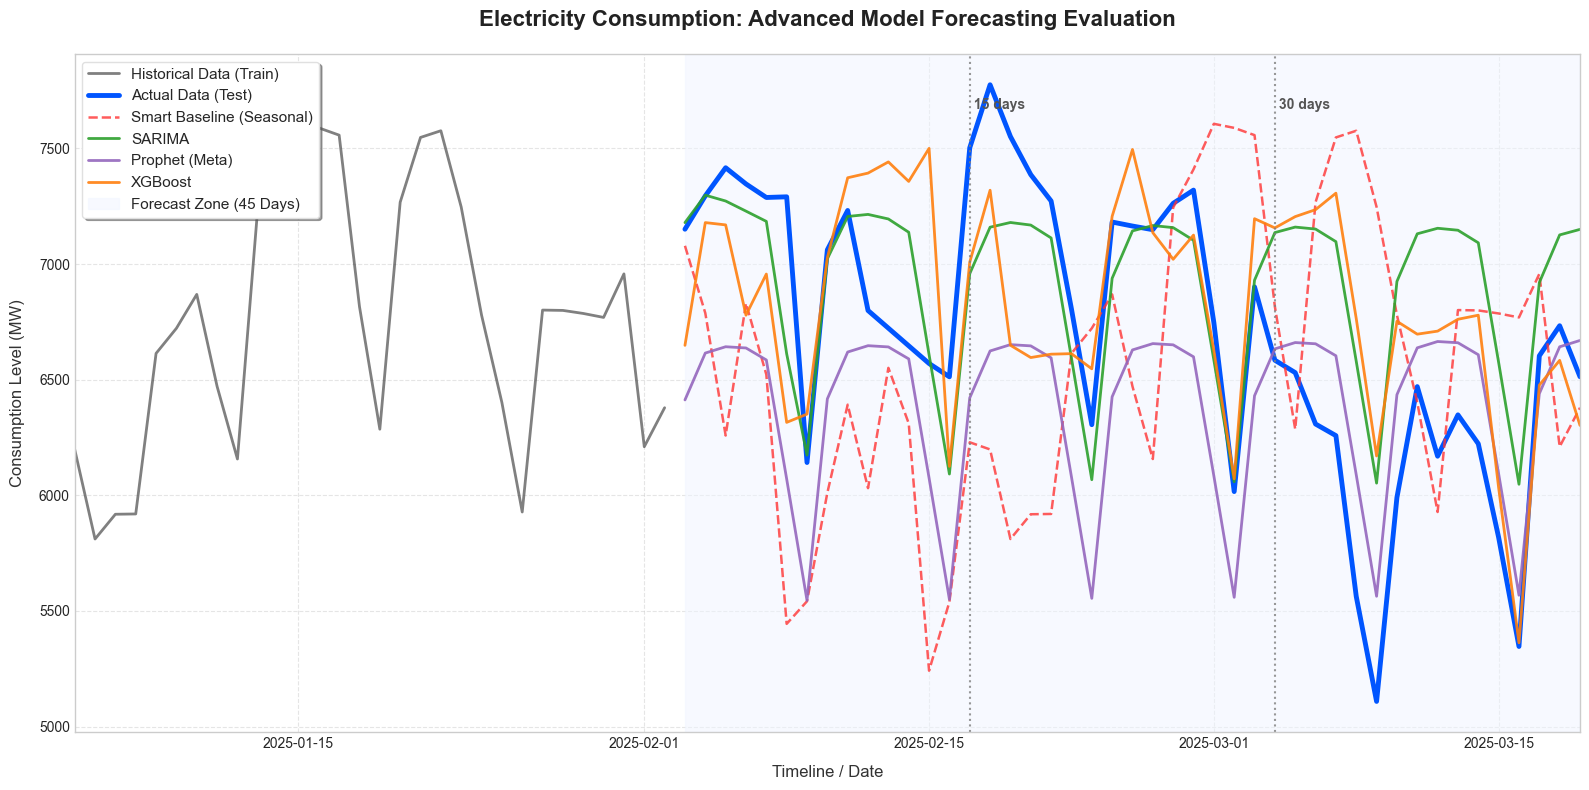

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

plt.figure(figsize=(16, 8), dpi=100)
history_window = 30
plt.plot(train_data.index[-history_window:], train_data.iloc[-history_window:], 
         label='Historical Data (Train)', color='#4A4A4A', linewidth=2, alpha=0.7)
plt.plot(test_data.index, test_data, label='Actual Data (Test)', color='#0055ff', linewidth=3.5)

plt.plot(test_data.index, smart_baseline_series, label='Smart Baseline (Seasonal)', color='#ff3333', linestyle='--', linewidth=1.8, alpha=0.8)
plt.plot(test_data.index, sarima_forecast_series, label='SARIMA', color='#2ca02c', linewidth=2, alpha=0.9)
plt.plot(test_data.index, prophet_forecast_series, label='Prophet (Meta)', color='#9467bd', linewidth=2, alpha=0.9)
plt.plot(test_data.index, xgb_forecast_series, label='XGBoost', color='#ff7f0e', linewidth=2, alpha=0.9)
plt.axvspan(test_data.index[0], test_data.index[-1], color='#f0f5ff', alpha=0.5, label='Forecast Zone (45 Days)')

plt.axvline(x=test_data.index[14], color='#7f7f7f', linestyle=':', linewidth=1.5, alpha=0.8)
plt.text(test_data.index[14], plt.ylim()[1]*0.97, ' 15 days', color='#555555', fontsize=10, fontweight='bold')

plt.axvline(x=test_data.index[29], color='#7f7f7f', linestyle=':', linewidth=1.5, alpha=0.8)
plt.text(test_data.index[29], plt.ylim()[1]*0.97, ' 30 days', color='#555555', fontsize=10, fontweight='bold')

plt.title('Electricity Consumption: Advanced Model Forecasting Evaluation', fontsize=16, fontweight='bold', pad=20, color='#222222')
plt.xlabel('Timeline / Date', fontsize=12, labelpad=10, color='#333333')
plt.ylabel('Consumption Level (MW)', fontsize=12, labelpad=10, color='#333333')

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=1, shadow=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
plt.autoscale(enable=True, axis='x', tight=True)

plt.tight_layout()
plt.show()